# Loan Default Prediction

## Feature Engineering

Author : Team 8
Role : Product Owner & ML Engineer

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("../data/processed/loan_default_processed.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   HasMortgage                   255347 non-null  int64  
 10  HasDependents                 255347 non-null  int64  
 11  HasCoSigner                   255347 non-null  int64  
 12  Default                       255347 non-null  int64  


In [4]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,...,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.500014,...,0.248826,0.251270,0.249488,0.249950,0.334063,0.332927,0.200895,0.199748,0.200848,0.199391
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.500001,...,0.432334,0.433744,0.432718,0.432985,0.471663,0.471262,0.400671,0.399812,0.400636,0.399544
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,1.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.columns.tolist()

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'HasMortgage',
 'HasDependents',
 'HasCoSigner',
 'Default',
 'Education_High School',
 "Education_Master's",
 'Education_PhD',
 'EmploymentType_Part-time',
 'EmploymentType_Self-employed',
 'EmploymentType_Unemployed',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'LoanPurpose_Business',
 'LoanPurpose_Education',
 'LoanPurpose_Home',
 'LoanPurpose_Other']

In [8]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,0,0,0,0,0,0,0,0,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,0,0,0,1,0,0,0,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,0,0,0,1,0,0,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,0,0,0,1,0,1,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,0,0,1,0,0,0,0,0,0


In [9]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Default', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']

Categorical Columns:
[]


In [10]:
# Check missing values in each column

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [11]:
# Count duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# Count the number of samples in each class

print(df['Default'].value_counts())

Default
0    225694
1     29653
Name: count, dtype: int64


In [13]:
# Calculate the percentage distribution

print(df['Default'].value_counts(normalize=True) * 100)

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


In [14]:
# Summary statistics of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
HasMortgage,255347.0,0.500014,0.500001,0.0,0.00,1.00,1.00,1.0


In [15]:
df.dtypes

Age                               int64
Income                            int64
LoanAmount                        int64
CreditScore                       int64
MonthsEmployed                    int64
NumCreditLines                    int64
InterestRate                    float64
LoanTerm                          int64
DTIRatio                        float64
HasMortgage                       int64
HasDependents                     int64
HasCoSigner                       int64
Default                           int64
Education_High School             int64
Education_Master's                int64
Education_PhD                     int64
EmploymentType_Part-time          int64
EmploymentType_Self-employed      int64
EmploymentType_Unemployed         int64
MaritalStatus_Married             int64
MaritalStatus_Single              int64
LoanPurpose_Business              int64
LoanPurpose_Education             int64
LoanPurpose_Home                  int64
LoanPurpose_Other                 int64


In [16]:
from sklearn.preprocessing import StandardScaler

# Continuous numerical columns
continuous_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

# Create scaler
scaler = StandardScaler()

# Scale only continuous columns
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [17]:
df[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,-1.812065e-16,1.000002,-1.700995,-0.833764,-0.033242,0.833990,1.701221
Income,255347.0,3.784411e-17,1.000002,-1.732398,-0.864252,-0.000855,0.865430,1.732408
LoanAmount,255347.0,4.147548e-17,1.000002,-1.730348,-0.867058,-0.000323,0.866822,1.728108
CreditScore,255347.0,2.335205e-16,1.000002,-1.725980,-0.863822,-0.001664,0.866788,1.728946
MonthsEmployed,255347.0,9.366418e-17,1.000002,-1.718715,-0.852747,0.013221,0.879189,1.716292
NumCreditLines,255347.0,-2.983007e-17,1.000002,-1.343791,-0.448549,-0.448549,0.446694,1.341937
InterestRate,255347.0,1.408024e-16,1.000002,-1.731770,-0.862327,-0.004938,0.867519,1.733948
LoanTerm,255347.0,1.861040e-16,1.000002,-1.415845,-0.708685,-0.001526,0.705634,1.412793
DTIRatio,255347.0,5.253654e-17,1.000002,-1.733149,-0.867034,-0.000918,0.865197,1.731312


In [18]:
df.to_csv("../data/processed/loan_feature_engineered.csv", index=False)

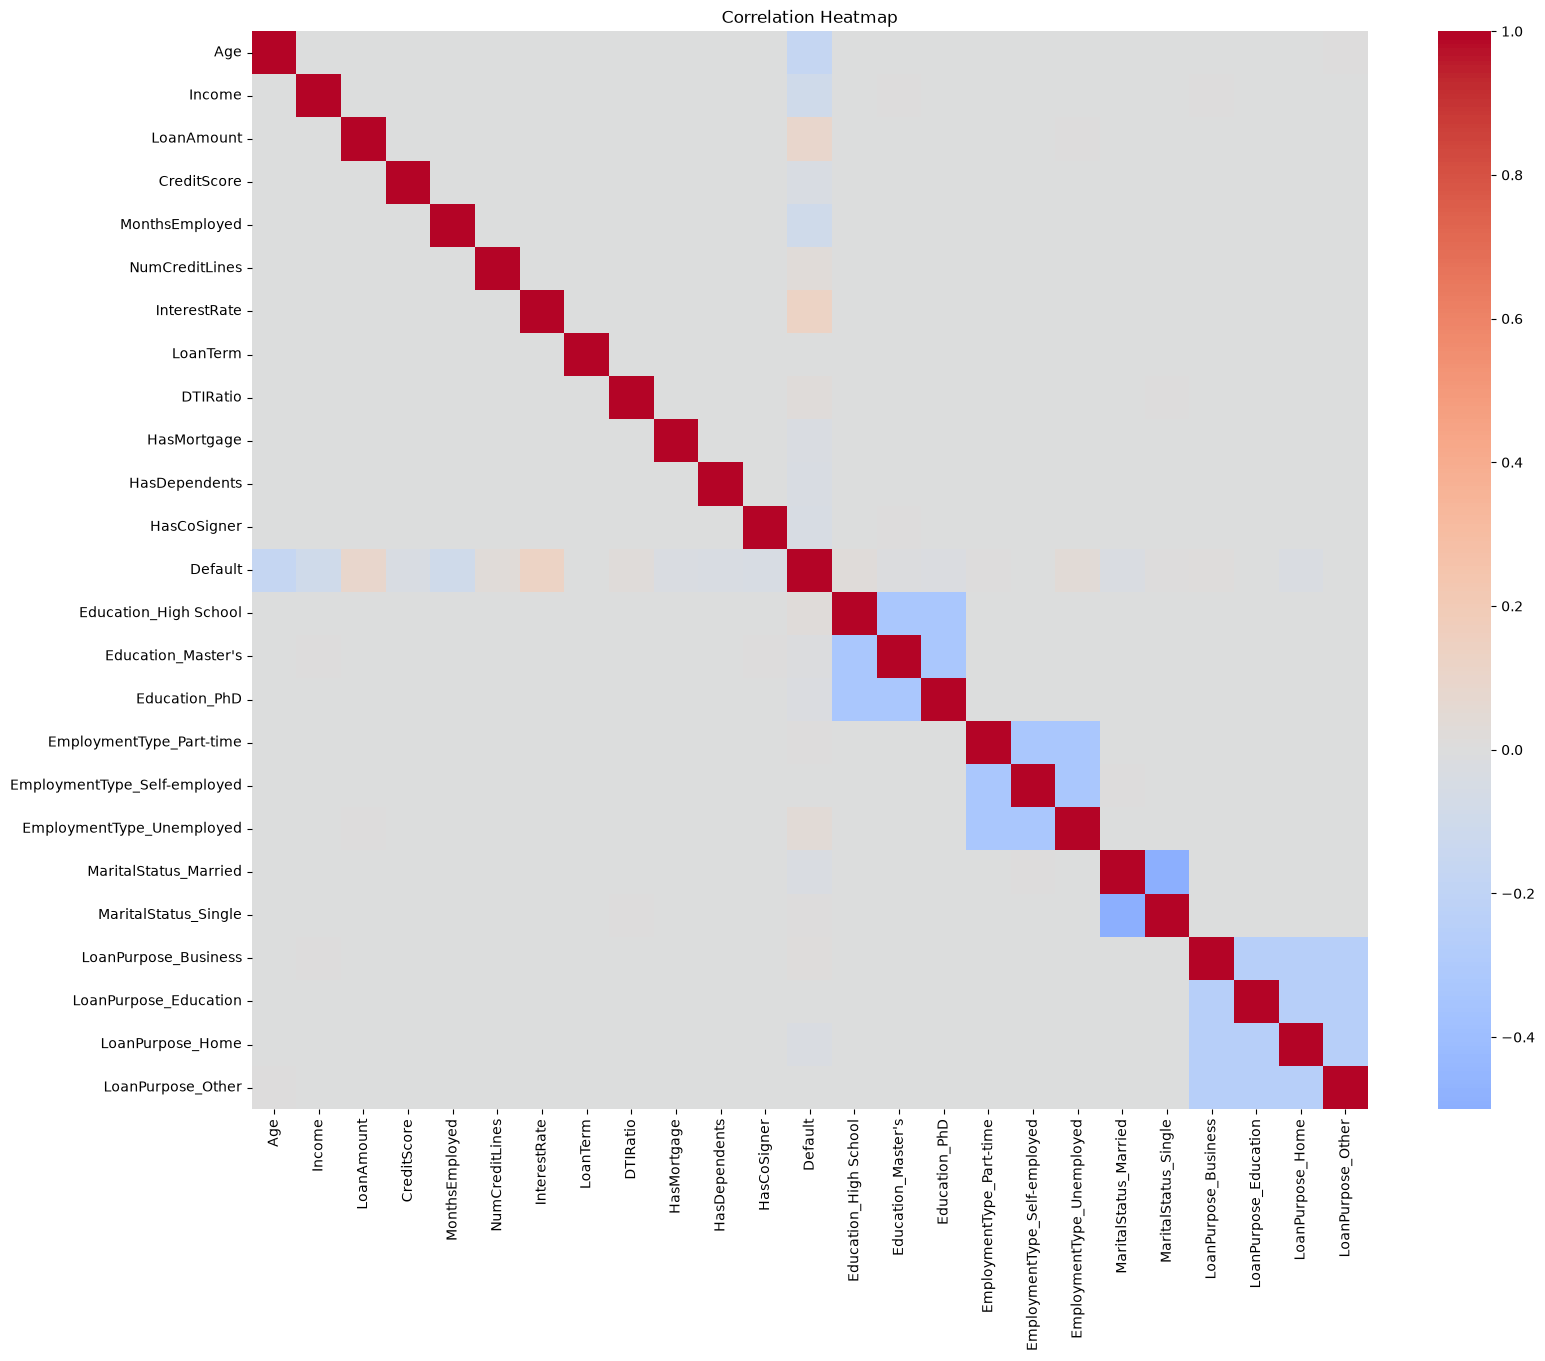

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

plt.title("Correlation Heatmap")
plt.show()

In [20]:
# Find highly correlated feature pairs

threshold = 0.90

corr_pairs = (
    corr_matrix.where(
        abs(corr_matrix) > threshold
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]

print(corr_pairs)

             Feature 1              Feature 2  Correlation
1                  Age                 Income          NaN
2                  Age             LoanAmount          NaN
3                  Age            CreditScore          NaN
4                  Age         MonthsEmployed          NaN
5                  Age         NumCreditLines          NaN
..                 ...                    ...          ...
619  LoanPurpose_Other  MaritalStatus_Married          NaN
620  LoanPurpose_Other   MaritalStatus_Single          NaN
621  LoanPurpose_Other   LoanPurpose_Business          NaN
622  LoanPurpose_Other  LoanPurpose_Education          NaN
623  LoanPurpose_Other       LoanPurpose_Home          NaN

[600 rows x 3 columns]


In [21]:
corr_matrix = df.corr(numeric_only=True)

# Extract upper triangle only
import numpy as np

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find highly correlated features
high_corr = upper.stack().reset_index()

high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Keep only correlations greater than 0.90
high_corr = high_corr[abs(high_corr['Correlation']) > 0.90]

print(high_corr)

Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []
